# Libraries and palettes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pypalettes import load_cmap
from pypalettes import get_hex
import networkx as nx

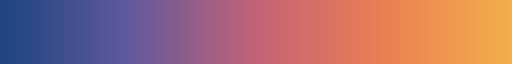

In [2]:
sunset2 = load_cmap('Sunset2', cmap_type='continuous')
sunset2

# Comprobations of RN Generation

mean: 1.702315638
std: 0    0.897682
dtype: float64
Theoretical mean: 1.7110914332847293
Theoretical std: 0.8944271909999159


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


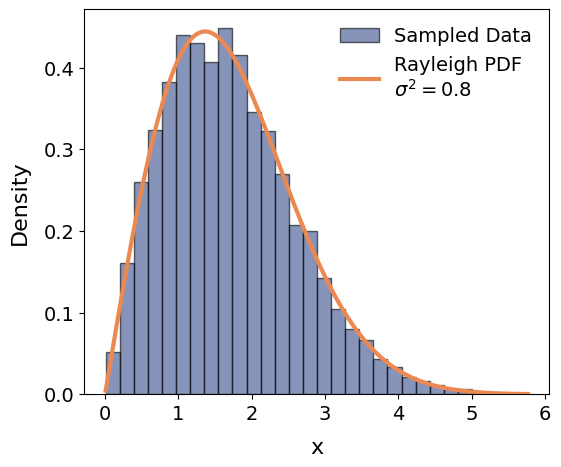

In [3]:
rayleigh_sample = pd.read_csv('test_rayleigh.txt', header = None)
print("mean:", np.mean(rayleigh_sample))
print("std:", np.std(rayleigh_sample))

# mean = 1.0;
# sigma = mean * np.sqrt(2.0 / np.pi);
variance = 0.8;
sigma = np.sqrt(variance*2/(4-np.pi))
mean = sigma * np.sqrt(np.pi / 2.0)
print('Theoretical mean:', mean)
print('Theoretical std:', np.sqrt((4 - np.pi) / 2.0 * sigma**2))
the_x = np.arange(np.min(rayleigh_sample), np.max(rayleigh_sample), 0.01)
the_y = (the_x / (sigma**2)) * np.exp(- (the_x**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(rayleigh_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Rayleigh PDF\n' r'$\sigma^2 = 0.8$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)


mean: 0.2953173248
std: 0    0.201887
dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(-1.2, 1.2)

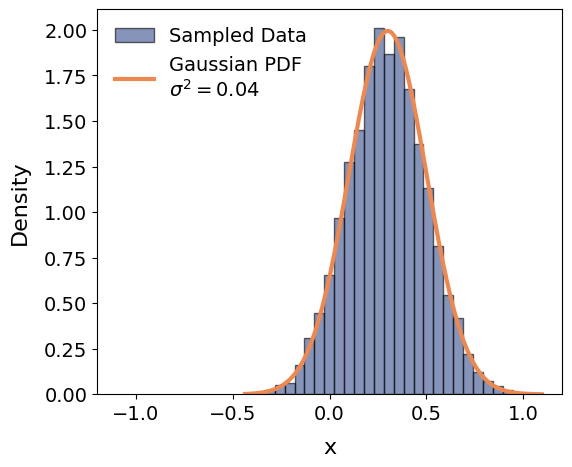

In [4]:
gaussian_sample = pd.read_csv('test_gaussian.txt', header = None)
print("mean:", np.mean(gaussian_sample))
print("std:", np.std(gaussian_sample))

mean = 0.3;
sigma = np.sqrt(0.04);
the_x = np.arange(np.min(gaussian_sample), np.max(gaussian_sample), 0.01)
the_y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(- ((the_x - mean)**2) / (2.0 * sigma**2))

plt.figure(figsize=(6,5))
plt.hist(gaussian_sample, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black', label='Sampled Data')
plt.plot(the_x, the_y, color=sunset2(0.8), linewidth=3, label='Gaussian PDF\n' r'$\sigma^2 = 0.04$')
plt.xlabel('x', fontsize = 16, labelpad = 10)
plt.ylabel('Density', fontsize = 16, labelpad = 10)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(fontsize = 14, loc = 'best', frameon = False)
plt.xlim(-1.2, 1.2)


# Neuronal network

C:\Users\Admin\AppData\Local\Temp\ipykernel_34224\746382228.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("networks/neurons_params_a0.50.txt", delim_whitespace=True)


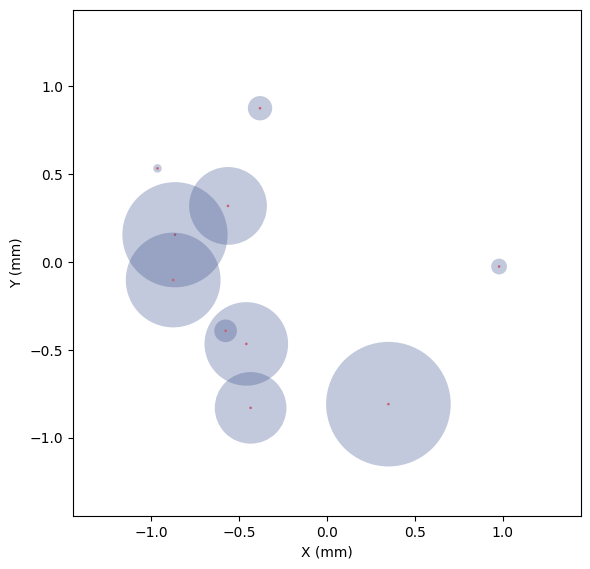

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Carga de datos: adapta el separador y el nombre del fichero
# Si es un .csv con comas:
# df = pd.read_csv("neuronas.txt")

# Si es un txt con espacios/tabuladores:
df = pd.read_csv("networks/neurons_params_a0.50.txt", delim_whitespace=True)

sub = df.head(10)

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in sub.iterrows():
    x = row["X"]
    y = row["Y"]
    soma_r = row["Soma_Diameter"] / 2.0          # mm
    dend_r = row["Dendrite_Diameter"] / 2.0      # mm

    # Círculo de dendritas (más grande y transparente)
    dend = Circle(
        (x, y),
        radius=dend_r,
        facecolor=sunset2(0.1),   # sin relleno, solo borde
        alpha=0.3
    )
    ax.add_patch(dend)

    # Círculo del soma (más pequeño y relleno)
    soma = Circle(
        (x, y),
        radius=soma_r,
        facecolor=sunset2(0.5),
        lw=0.8
    )
    ax.add_patch(soma)

# Límites del gráfico: dejamos un pequeño margen según el tamaño de las dendritas
max_r = (df["Dendrite_Diameter"] / 2.0).max()
xmin = df["X"].min() - max_r
xmax = df["X"].max() + max_r
ymin = df["Y"].min() - max_r
ymax = df["Y"].max() + max_r

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_34224\378901815.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  adjacency_matrix = pd.read_csv(file_adjacency_matrix, delim_whitespace=True, header=None)


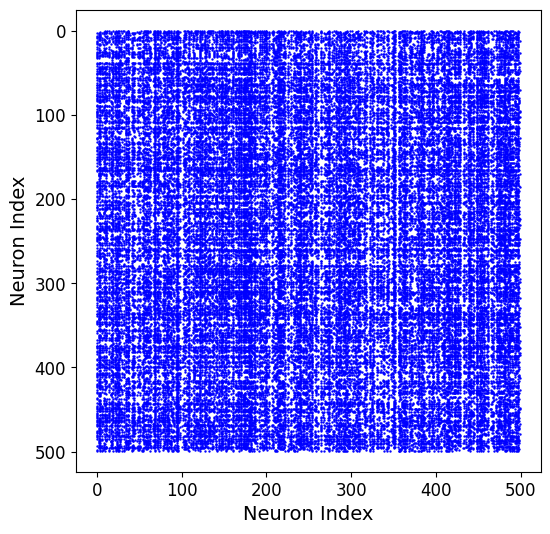

In [12]:
file_adjacency_matrix = 'networks/adjacency_matrix_a0.50.txt'
adjacency_matrix = pd.read_csv(file_adjacency_matrix, delim_whitespace=True, header=None)

rows, cols = np.where(adjacency_matrix.values == 1)

plt.figure(figsize=(6, 6))
plt.scatter(cols, rows, s=0.5, color='blue')
plt.gca().invert_yaxis()
plt.xlabel('Neuron Index', fontsize=14)
plt.ylabel('Neuron Index', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import os

import numpy as np

def read_adj_01txt(path, N=500):
    with open(path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    if len(lines) != N:
        raise ValueError(f"{path}: {len(lines)} líneas, esperado {N}")
    # convierte caracteres '0'/'1' a uint8
    A = np.frombuffer(("".join(lines)).encode("ascii"), dtype=np.uint8) - ord('0')
    return A.reshape(N, N)



alpha = np.arange(0, 0.99, 0.0010)
filenames = [f'networks/adjacency_matrix_a{a:.4f}.txt' for a in alpha]
filenames = [f for f in filenames if os.path.exists(f)]
degrees = []
stds = []

for file in filenames:
    A = read_adj_01txt(file, N=500)
    np.fill_diagonal(A, 0)
    deg = A.sum(axis=1)
    degrees.append(deg.mean())
    stds.append(deg.std())

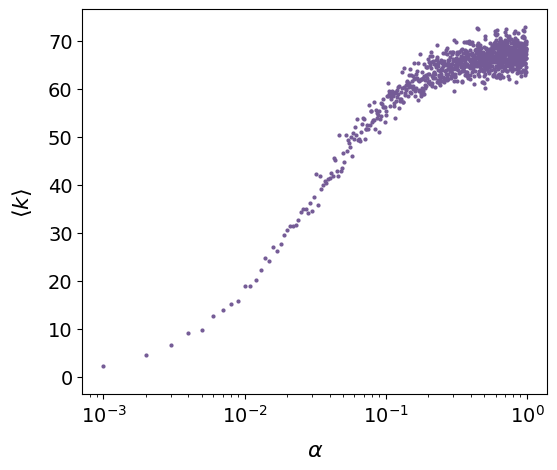

In [66]:
plt.figure(figsize=(6,5))
plt.plot(alpha, degrees, marker = 'o', markersize = 2, linestyle='-', lw = 0, color = sunset2(0.3))
plt.xlabel(r'$\alpha$', fontsize=16, labelpad=10)
plt.ylabel(r'$\langle k\rangle$', fontsize=16, labelpad=10)
plt.xscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim(0, 0.3)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_34224\807474327.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  adjacency_matrix = pd.read_csv(filename, delim_whitespace=True, header=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_34224\807474327.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  neuron_params = pd.read_csv('networks/neurons_params_a0.50.txt', delim_whitespace=True)
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\networkx\drawing\nx_pylab.py:1497: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA

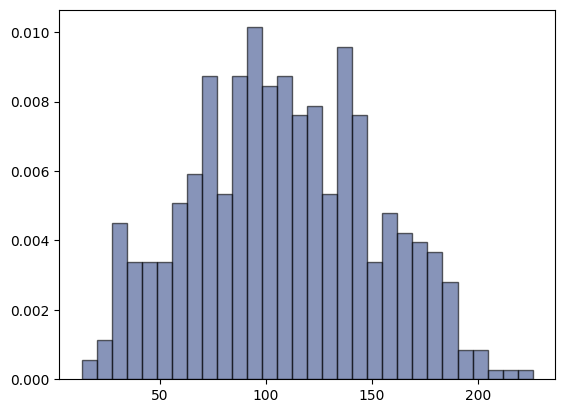

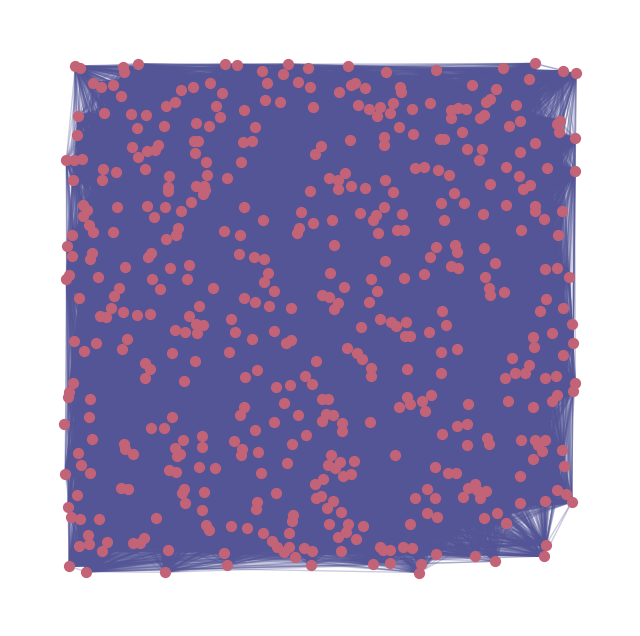

In [13]:
filename = 'networks/adjacency_matrix_a0.50.txt'
adjacency_matrix = pd.read_csv(filename, delim_whitespace=True, header=None)
neuron_params = pd.read_csv('networks/neurons_params_a0.50.txt', delim_whitespace=True)

X = neuron_params['X'].values
Y = neuron_params['Y'].values

G = adj_to_graph(adjacency_matrix)
degree_distribution = adjacency_matrix.sum(axis=1)

plt.hist(degree_distribution, bins=30, density=True, alpha=0.6, color=sunset2(0.1), edgecolor='black')

pos = {i: (X[i], Y[i]) for i in range(len(X))}  # Posiciones de los nodos basadas en X e Y
plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=sunset2(0.5))

nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color=sunset2(0.2))
plt.axis('off')
plt.show()
